In [1]:
import json

fichier = "raw0.json"

with open(fichier, "r", encoding="utf-8") as f: 
    for i in range(3):
        ligne = f.readline()

        tweet = json.loads(ligne) 

        print(tweet) 
        print("\n============\n")

{'created_date': '2018-06-14 04:14:25', 'current_time': 1528942465098, 'in_reply_to_status_id_str': None, 'in_reply_to_status_id': None, 'created_at': 'Thu Jun 14 02:14:24 +0000 2018', 'in_reply_to_user_id_str': None, 'source': '<a href="http://twitter.com/download/iphone" rel="nofollow">Twitter for iPhone</a>', 'retweeted_status': {'extended_entities': {'media': [{'display_url': 'pic.twitter.com/sL9ROvLJSx', 'indices': [106, 129], 'sizes': {'small': {'w': 680, 'h': 314, 'resize': 'fit'}, 'large': {'w': 1110, 'h': 512, 'resize': 'fit'}, 'thumb': {'w': 150, 'h': 150, 'resize': 'crop'}, 'medium': {'w': 1110, 'h': 512, 'resize': 'fit'}}, 'id_str': '1006971174125883393', 'expanded_url': 'https://twitter.com/HoustonRockets/status/1006976904585498624/photo/1', 'media_url_https': 'https://pbs.twimg.com/media/Dfl68pzU0AEWyCh.jpg', 'id': 1006971174125883393, 'type': 'photo', 'media_url': 'http://pbs.twimg.com/media/Dfl68pzU0AEWyCh.jpg', 'url': 'https://t.co/sL9ROvLJSx'}]}, 'in_reply_to_status_i

In [2]:
print(tweet.keys())

dict_keys(['created_date', 'current_time', 'quoted_status', 'in_reply_to_status_id_str', 'in_reply_to_status_id', 'created_at', 'in_reply_to_user_id_str', 'source', 'retweeted_status', 'quoted_status_id', 'retweet_count', 'retweeted', 'geo', 'filter_level', 'in_reply_to_screen_name', 'is_quote_status', 'id_str', 'in_reply_to_user_id', 'favorite_count', 'id', 'text', 'place', 'quoted_status_permalink', 'lang', 'quote_count', 'favorited', 'possibly_sensitive', 'coordinates', 'truncated', 'timestamp_ms', 'reply_count', 'entities', 'quoted_status_id_str', 'contributors', 'user'])


In [3]:
print(tweet["user"].keys())

dict_keys(['utc_offset', 'friends_count', 'profile_image_url_https', 'listed_count', 'profile_background_image_url', 'default_profile_image', 'favourites_count', 'description', 'created_at', 'is_translator', 'profile_background_image_url_https', 'protected', 'screen_name', 'id_str', 'profile_link_color', 'translator_type', 'id', 'geo_enabled', 'profile_background_color', 'lang', 'profile_sidebar_border_color', 'profile_text_color', 'verified', 'profile_image_url', 'time_zone', 'url', 'contributors_enabled', 'profile_background_tile', 'profile_banner_url', 'statuses_count', 'follow_request_sent', 'followers_count', 'profile_use_background_image', 'default_profile', 'following', 'name', 'location', 'profile_sidebar_fill_color', 'notifications'])


In [4]:
user = tweet["user"]
entities = tweet["entities"]

features = {

    # ===== Variables utilisateur =====
    "user_id": user["id"],
    "screen_name": user["screen_name"],
    "followers_count": user["followers_count"],
    "friends_count": user["friends_count"],
    "statuses_count": user["statuses_count"],
    "verified": user["verified"],
    "default_profile": user["default_profile"],
    "default_profile_image": user["default_profile_image"],
    "favourites_count": user["favourites_count"],
    "listed_count": user["listed_count"],

    # ===== Variables tweet =====
    "retweet_count": tweet["retweet_count"],
    "favorite_count": tweet["favorite_count"],
    "reply_count": tweet["reply_count"],
    "quote_count": tweet["quote_count"],
    "lang": tweet["lang"],

    # ===== Variables contenu =====
    "hashtags_count": len(entities["hashtags"]),
    "urls_count": len(entities["urls"]),
    "mentions_count": len(entities["user_mentions"]),

    # ===== Longueur du tweet =====
    "tweet_length": len(tweet["text"])
}

print(features)

{'user_id': 967244973824339968, 'screen_name': 'tokenbrotha', 'followers_count': 34, 'friends_count': 44, 'statuses_count': 4219, 'verified': False, 'default_profile': False, 'default_profile_image': False, 'favourites_count': 2131, 'listed_count': 0, 'retweet_count': 0, 'favorite_count': 0, 'reply_count': 0, 'quote_count': 0, 'lang': 'en', 'hashtags_count': 0, 'urls_count': 1, 'mentions_count': 1, 'tweet_length': 46}


In [5]:
import json
import pandas as pd

fichier = "raw0.json"

data = []

with open(fichier, "r", encoding="utf-8") as f:
    for ligne in f:
        
        tweet = json.loads(ligne)
        user = tweet["user"]
        entities = tweet["entities"]

        features = {
            "user_id": user["id"],
            "screen_name": user["screen_name"],
            "followers_count": user["followers_count"],
            "friends_count": user["friends_count"],
            "statuses_count": user["statuses_count"],
            "verified": user["verified"],
            "default_profile": user["default_profile"],
            "default_profile_image": user["default_profile_image"],
            "favourites_count": user["favourites_count"],
            "listed_count": user["listed_count"],

            "retweet_count": tweet["retweet_count"],
            "favorite_count": tweet["favorite_count"],
            "reply_count": tweet["reply_count"],
            "quote_count": tweet["quote_count"],
            "lang": tweet["lang"],

            "hashtags_count": len(entities["hashtags"]),
            "urls_count": len(entities["urls"]),
            "mentions_count": len(entities["user_mentions"]),

            "tweet_length": len(tweet["text"])
        }

        data.append(features)

df = pd.DataFrame(data)

df.head()

,user_id,screen_name,followers_count,friends_count,statuses_count,verified,default_profile,default_profile_image,favourites_count,listed_count,retweet_count,favorite_count,reply_count,quote_count,lang,hashtags_count,urls_count,mentions_count,tweet_length
0,39084553,JojoHtown,556,826,32153,False,True,False,17414,24,0,0,0,0,en,2,0,1,140
1,1564678657,tricoloraphael,918,686,28445,False,True,False,15412,5,0,0,0,0,pt,0,1,0,51
2,967244973824339968,tokenbrotha,34,44,4219,False,False,False,2131,0,0,0,0,0,en,0,1,1,46
3,4872447178,irashediat,2805,3189,5162,False,True,False,144,5,0,0,0,0,ar,2,0,1,140
4,35628099,aminelion,48,407,487,False,False,False,1124,1,0,0,0,0,en,2,0,2,140


In [6]:
df.shape

(1999, 19)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1999 entries, 0 to 1998
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   user_id                1999 non-null   int64 
 1   screen_name            1999 non-null   object
 2   followers_count        1999 non-null   int64 
 3   friends_count          1999 non-null   int64 
 4   statuses_count         1999 non-null   int64 
 5   verified               1999 non-null   bool  
 6   default_profile        1999 non-null   bool  
 7   default_profile_image  1999 non-null   bool  
 8   favourites_count       1999 non-null   int64 
 9   listed_count           1999 non-null   int64 
 10  retweet_count          1999 non-null   int64 
 11  favorite_count         1999 non-null   int64 
 12  reply_count            1999 non-null   int64 
 13  quote_count            1999 non-null   int64 
 14  lang                   1999 non-null   object
 15  hashtags_count       

In [8]:
df.describe()

,user_id,followers_count,friends_count,statuses_count,favourites_count,listed_count,retweet_count,favorite_count,reply_count,quote_count,hashtags_count,urls_count,mentions_count,tweet_length
count,1.999000e+03,1.999000e+03,1999.000000,1.999000e+03,1999.000000,1999.000000,1999.0,1999.0,1999.0,1999.0,1999.000000,1999.000000,1999.000000,1999.000000
mean,2.312484e+17,7.940864e+03,1338.041521,2.997250e+04,10752.636818,35.616808,0.0,0.0,0.0,0.0,1.582791,0.279640,1.018509,113.255128
std,3.921062e+17,1.051414e+05,6881.978078,6.866761e+04,28971.266639,219.645798,0.0,0.0,0.0,0.0,1.813922,0.457767,1.030155,34.157073
min,2.232071e+06,0.000000e+00,0.000000,2.000000e+00,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,9.000000
25%,3.287409e+08,1.370000e+02,173.000000,1.751000e+03,302.500000,0.000000,0.0,0.0,0.0,0.0,1.000000,0.000000,0.000000,90.000000
50%,1.558198e+09,3.840000e+02,390.000000,9.139000e+03,2178.000000,4.000000,0.0,0.0,0.0,0.0,1.000000,0.000000,1.000000,134.000000
75%,7.149721e+17,1.219500e+03,969.000000,2.897350e+04,8961.000000,13.000000,0.0,0.0,0.0,0.0,2.000000,1.000000,1.000000,140.000000
max,1.007083e+18,3.964570e+06,248327.000000,1.140288e+06,571722.000000,6110.000000,0.0,0.0,0.0,0.0,25.000000,2.000000,10.000000,146.000000


In [9]:
df["user_id"].nunique()

1703

In [10]:
df["screen_name"].nunique()

1703

In [11]:
user_df = df.groupby("user_id").agg({
    "followers_count": "mean",
    "friends_count": "mean",
    "statuses_count": "mean",
    "favourites_count": "mean",
    "listed_count": "mean",
    "hashtags_count": "mean",
    "urls_count": "mean",
    "mentions_count": "mean",
    "tweet_length": "mean"
})

In [12]:
user_df.head()

,followers_count,friends_count,statuses_count,favourites_count,listed_count,hashtags_count,urls_count,mentions_count,tweet_length
user_id,,,,,,,,,
2232071,340.0,239.0,4385.0,3863.0,15.0,1.0,0.0,1.0,140.0
3554081,388.0,1103.0,9871.0,55594.0,12.0,0.0,2.0,0.0,98.0
6509832,3964570.0,399.0,590150.0,166.0,6110.0,3.0,1.0,0.0,126.0
9451042,1027.0,998.0,12660.0,291.0,72.0,1.0,1.0,0.0,114.0
14338267,1616.0,2625.0,56560.0,132292.0,125.0,0.0,0.0,1.0,140.0


In [13]:
user_df.shape

(1703, 9)

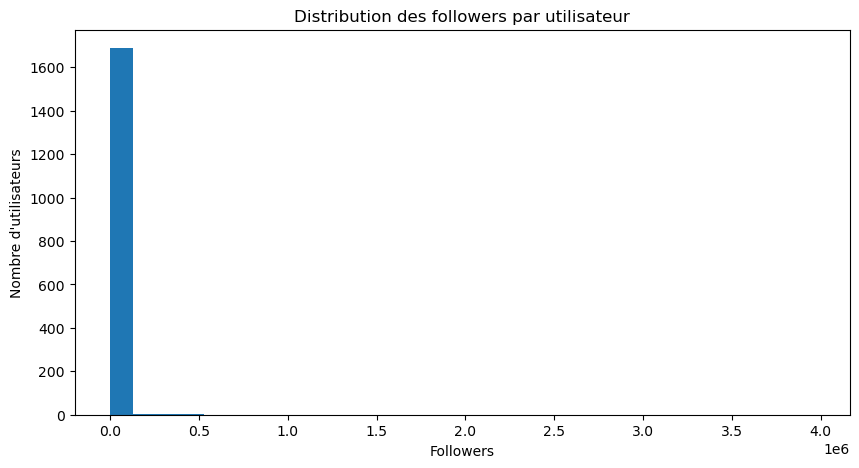

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(user_df["followers_count"], bins=30)

plt.title("Distribution des followers par utilisateur")
plt.xlabel("Followers")
plt.ylabel("Nombre d'utilisateurs")

plt.show()

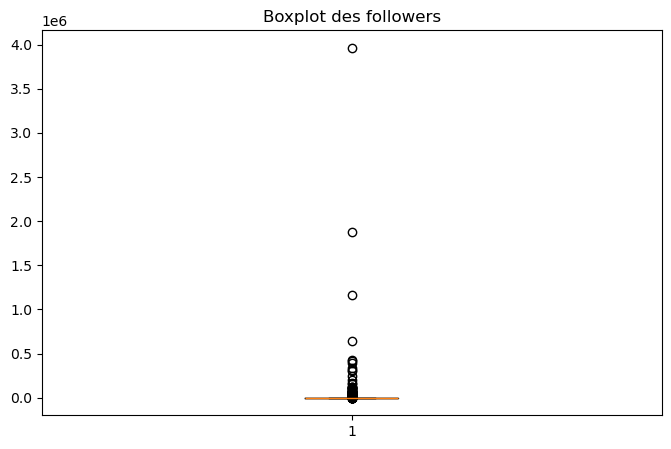

In [15]:
plt.figure(figsize=(8,5))

plt.boxplot(user_df["followers_count"])

plt.title("Boxplot des followers")

plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
features = user_df.copy()

In [19]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(features)

In [20]:
scaled_data[:5]

array([[-7.55931981e-02, -1.52620604e-01, -3.78310277e-01,
        -2.41225555e-01, -9.84521299e-02, -3.19301167e-01,
        -6.38154928e-01,  9.00536679e-03,  8.04683298e-01],
       [-7.51714765e-02, -3.48404344e-02, -2.90407926e-01,
         1.48449497e+00, -1.11195136e-01, -9.01872030e-01,
         3.72921069e+00, -1.01780544e+00, -4.24977056e-01],
       [ 3.47536014e+01, -1.30809461e-01,  9.00742072e+00,
        -3.64555643e-01,  2.57910883e+01,  8.45840560e-01,
         1.54552788e+00, -1.01780544e+00,  3.94796513e-01],
       [-6.95573080e-02, -4.91539966e-02, -2.45719692e-01,
        -3.60385705e-01,  1.43664984e-01, -3.19301167e-01,
         1.54552788e+00, -1.01780544e+00,  4.34649838e-02],
       [-6.43824328e-02,  1.72638058e-01,  4.57691387e-01,
         4.04310225e+00,  3.68791422e-01, -9.01872030e-01,
        -6.38154928e-01,  9.00536679e-03,  8.04683298e-01]])

In [21]:
from sklearn.decomposition import PCA

In [22]:
pca = PCA(n_components=2)

In [23]:
pca_result = pca.fit_transform(scaled_data)

In [24]:
pca_df = pd.DataFrame(
    data=pca_result,
    columns=["PC1", "PC2"]
)

In [25]:
pca_df.head()

,PC1,PC2
0,-0.398279,0.611482
1,0.480058,-2.836558
2,41.309105,2.526619
3,0.176541,-1.524175
4,0.808181,1.179057


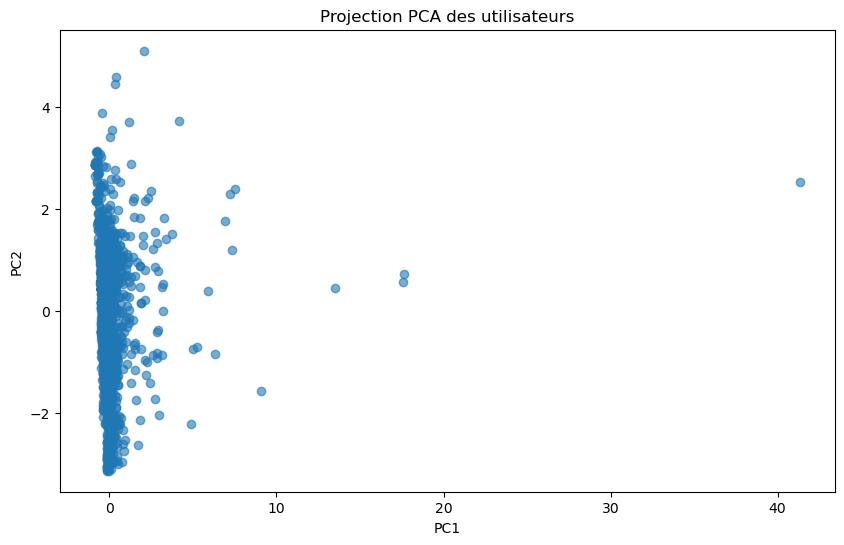

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.6
)

plt.title("Projection PCA des utilisateurs")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.show()

In [27]:
from sklearn.cluster import DBSCAN

In [28]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

In [29]:
clusters = dbscan.fit_predict(pca_df)

In [30]:
pca_df["cluster"] = clusters

In [31]:
pca_df["cluster"].value_counts()

cluster
 0    1683
-1      20
Name: count, dtype: int64

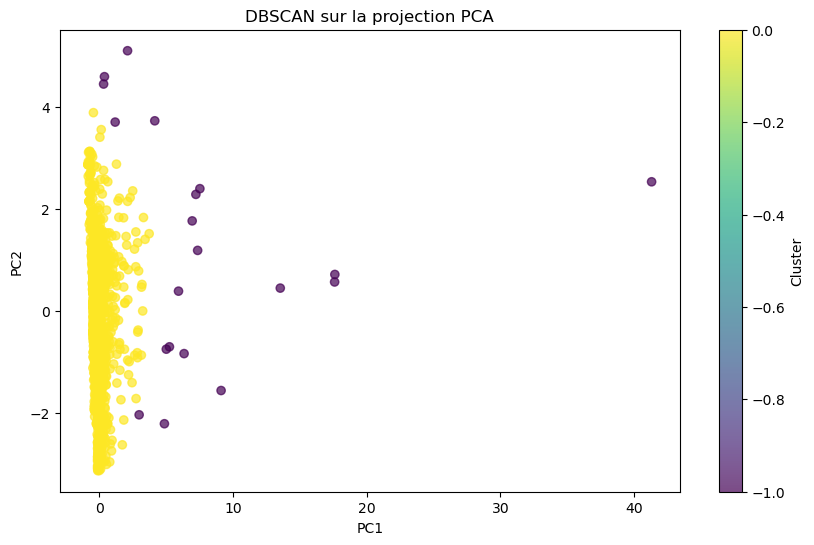

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    cmap="viridis",
    alpha=0.7
)

plt.title("DBSCAN sur la projection PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")

plt.colorbar(label="Cluster")

plt.show()

In [33]:
anomalies = pca_df[pca_df["cluster"] == -1]

anomalies.head()

,PC1,PC2,cluster
2,41.309105,2.526619,-1
12,13.528113,0.445786,-1
23,17.594052,0.565639,-1
33,4.859168,-2.209069,-1
70,5.235482,-0.703255,-1


La projection PCA couplée à l’algorithme DBSCAN met en évidence un cluster principal regroupant la majorité des profils utilisateurs, ainsi qu’un ensemble réduit de profils atypiques identifiés comme du bruit (cluster = -1). Certains profils présentent une forte distance dans l’espace des composantes principales, suggérant des comportements très différents du comportement moyen observé dans le dataset.

In [35]:
user_df["cluster"] = clusters

anomalies_originales = user_df[user_df["cluster"] == -1]

anomalies_originales.head()

,followers_count,friends_count,statuses_count,favourites_count,listed_count,hashtags_count,urls_count,mentions_count,tweet_length,cluster
user_id,,,,,,,,,,
6509832,3964570.0,399.0,590150.0,166.0,6110.0,3.0,1.0,0.0,126.0,-1
17134268,340514.0,2436.0,107289.0,7977.0,4161.0,1.0,1.0,1.0,127.0,-1
21094888,1166848.0,2223.0,412099.0,8999.0,3249.0,2.0,1.0,0.0,123.0,-1
23536653,113732.0,84214.0,156073.0,27515.0,497.0,1.0,1.0,0.0,52.0,-1
38642509,168682.0,6000.0,170082.0,4991.0,1193.0,1.0,1.0,0.0,129.0,-1


In [36]:
anomalies_originales.describe()

,followers_count,friends_count,statuses_count,favourites_count,listed_count,hashtags_count,urls_count,mentions_count,tweet_length,cluster
count,2.000000e+01,20.000000,2.000000e+01,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.0
mean,4.724537e+05,20741.250000,2.798416e+05,54219.850000,1348.600000,4.000000,0.550000,1.050000,121.200000,-1.0
std,9.493541e+05,57003.685331,3.024804e+05,128049.696815,1621.447612,6.928203,0.510418,1.820208,28.139876,0.0
min,4.370000e+02,5.000000,8.428000e+03,0.000000,7.000000,1.000000,0.000000,0.000000,40.000000,-1.0
25%,2.055000e+03,375.000000,9.635000e+04,624.000000,212.000000,1.000000,0.000000,0.000000,120.250000,-1.0
50%,9.562500e+04,2000.000000,1.630775e+05,8488.000000,573.000000,1.500000,1.000000,0.500000,129.000000,-1.0
75%,4.235910e+05,5170.500000,3.730832e+05,45451.500000,1922.500000,3.000000,1.000000,1.000000,140.000000,-1.0
max,3.964570e+06,248327.000000,1.140288e+06,571722.000000,6110.000000,25.000000,1.000000,7.000000,140.000000,-1.0


Les profils détectés comme anomalies présentent des caractéristiques fortement différentes du comportement moyen :

nombre de followers extrêmement élevé ;
activité anormalement importante ;
nombre élevé d’abonnements ;
forte visibilité (listed_count) ;
comportement inhabituel dans l’espace PCA.

Ces profils peuvent correspondre à des bots, des comptes automatisés, des médias ou des utilisateurs fortement influents.

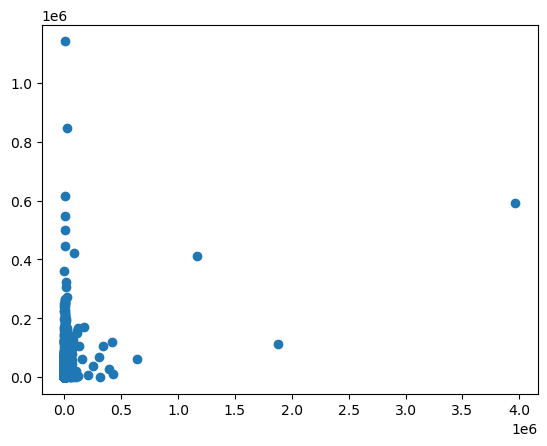

In [37]:
plt.scatter(
    user_df["followers_count"],
    user_df["statuses_count"]
)

In [38]:
anomalies_originales.to_csv("anomalies.csv")

In [39]:
from pymongo import MongoClient
client = MongoClient("mongodb://localhost:27017/")
print(client.list_database_names())

ModuleNotFoundError: No module named 'pymongo'

In [40]:
!pip install pymongo

  Using cached pymongo-4.17.0-cp313-cp313-win_amd64.whl.metadata (10 kB)
  Using cached dnspython-2.8.0-py3-none-any.whl.metadata (5.7 kB)
Using cached pymongo-4.17.0-cp313-cp313-win_amd64.whl (972 kB)
Using cached dnspython-2.8.0-py3-none-any.whl (331 kB)

   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   -------------------- ------------------- 1/2 [pymongo]
   -------------------- ------------------- 1/2 [pymongo]
   -------------------- ------------------- 1/2 [pymongo]
   -------------------- ------------------- 1/2 [pymongo]
   -------------------- ------------------- 1/2 [pymongo]
   -------------------- ------------------- 1/2 [pymongo]
   ---------------------------------------- 2/2 [pymongo]



In [44]:
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")

print(client.list_database_names())

['admin', 'config', 'local']


In [45]:
import json
import glob
from pymongo import MongoClient

# Connexion MongoDB
client = MongoClient("mongodb://localhost:27017/")

db = client["if29_twitter"]

collection = db["tweets_features"]

# Vider la collection avant insertion
collection.delete_many({})

# Chemin des fichiers JSON
chemin_dossier = r"C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw"

# Tous les fichiers raw0.json, raw1.json, etc.
fichiers = sorted(glob.glob(chemin_dossier + "/raw*.json"))

print("Nombre de fichiers trouvés :", len(fichiers))

documents = []

for fichier in fichiers:

    print("Traitement :", fichier)

    with open(fichier, "r", encoding="utf-8") as f:

        for ligne in f:

            try:
                tweet = json.loads(ligne)

                user = tweet["user"]
                entities = tweet["entities"]

                doc = {

                    # ===== Variables utilisateur =====
                    "user_id": user["id"],
                    "screen_name": user["screen_name"],
                    "followers_count": user["followers_count"],
                    "friends_count": user["friends_count"],
                    "statuses_count": user["statuses_count"],
                    "verified": user["verified"],
                    "default_profile": user["default_profile"],
                    "default_profile_image": user["default_profile_image"],
                    "favourites_count": user["favourites_count"],
                    "listed_count": user["listed_count"],

                    # ===== Variables tweet =====
                    "retweet_count": tweet["retweet_count"],
                    "favorite_count": tweet["favorite_count"],
                    "reply_count": tweet["reply_count"],
                    "quote_count": tweet["quote_count"],
                    "lang": tweet["lang"],

                    # ===== Contenu =====
                    "hashtags_count": len(entities["hashtags"]),
                    "urls_count": len(entities["urls"]),
                    "mentions_count": len(entities["user_mentions"]),

                    # ===== Taille tweet =====
                    "tweet_length": len(tweet["text"]),

                    # ===== Provenance =====
                    "source_file": fichier
                }

                documents.append(doc)

            except Exception as e:
                print("Erreur :", e)

# Insertion MongoDB
if documents:
    collection.insert_many(documents)

print("Insertion terminée")

print("Nombre total de documents :",
      collection.count_documents({}))

Nombre de fichiers trouvés : 2285
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw0.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw10.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw100.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1000.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1001.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1002.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1003.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1004.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1005.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1006.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1007.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1008.json
Traitement : C:\Users\Demo\Desktop\IF29

In [1]:
import glob

fichiers = glob.glob(r"C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\*.json")

print(len(fichiers))
print(fichiers[:5])

2285
['C:\\Users\\Demo\\Desktop\\IF29\\Tweet Worldcup\\raw\\raw0.json', 'C:\\Users\\Demo\\Desktop\\IF29\\Tweet Worldcup\\raw\\raw1.json', 'C:\\Users\\Demo\\Desktop\\IF29\\Tweet Worldcup\\raw\\raw10.json', 'C:\\Users\\Demo\\Desktop\\IF29\\Tweet Worldcup\\raw\\raw100.json', 'C:\\Users\\Demo\\Desktop\\IF29\\Tweet Worldcup\\raw\\raw1000.json']


In [2]:
import json
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:27017/")

db = client["if29_twitter"]

collection = db["tweets_features"]

collection.delete_many({})

batch = []
batch_size = 5000
total = 0

for fichier in fichiers:

    print("Traitement :", fichier)

    with open(fichier, "r", encoding="utf-8") as f:

        for ligne in f:

            try:
                tweet = json.loads(ligne)

                user = tweet["user"]
                entities = tweet["entities"]

                doc = {

                    "user_id": user.get("id"),
                    "screen_name": user.get("screen_name"),

                    "followers_count": user.get("followers_count"),
                    "friends_count": user.get("friends_count"),
                    "statuses_count": user.get("statuses_count"),

                    "verified": user.get("verified"),
                    "default_profile": user.get("default_profile"),
                    "default_profile_image": user.get("default_profile_image"),

                    "favourites_count": user.get("favourites_count"),
                    "listed_count": user.get("listed_count"),

                    "retweet_count": tweet.get("retweet_count"),
                    "favorite_count": tweet.get("favorite_count"),
                    "reply_count": tweet.get("reply_count"),
                    "quote_count": tweet.get("quote_count"),

                    "lang": tweet.get("lang"),

                    "hashtags_count": len(entities.get("hashtags", [])),
                    "urls_count": len(entities.get("urls", [])),
                    "mentions_count": len(entities.get("user_mentions", [])),

                    "tweet_length": len(tweet.get("text", "")),

                    "source_file": fichier
                }

                batch.append(doc)

                if len(batch) >= batch_size:

                    collection.insert_many(batch)

                    total += len(batch)

                    print("Tweets insérés :", total)

                    batch = []

            except:
                pass

if batch:

    collection.insert_many(batch)

    total += len(batch)

print("Insertion terminée")
print("Total :", total)
print("Documents MongoDB :", collection.count_documents({}))

Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw0.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw10.json
Tweets insérés : 5000
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw100.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1000.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1001.json
Tweets insérés : 10000
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1002.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1003.json
Tweets insérés : 15000
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1004.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1005.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1006.json
Tweets insérés : 20000
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup\raw\raw1007.json
Traitement : C:\Users\Demo\Desktop\IF29\Tweet Worldcup

In [3]:
collection.find_one()

{'_id': ObjectId('6a099370c712650f9ca02337'),
 'user_id': 39084553,
 'screen_name': 'JojoHtown',
 'followers_count': 556,
 'friends_count': 826,
 'statuses_count': 32153,
 'verified': False,
 'default_profile': True,
 'default_profile_image': False,
 'favourites_count': 17414,
 'listed_count': 24,
 'retweet_count': 0,
 'favorite_count': 0,
 'reply_count': 0,
 'quote_count': 0,
 'lang': 'en',
 'hashtags_count': 2,
 'urls_count': 0,
 'mentions_count': 1,
 'tweet_length': 140,
 'source_file': 'C:\\Users\\Demo\\Desktop\\IF29\\Tweet Worldcup\\raw\\raw0.json'}

In [4]:
len(collection.distinct("user_id"))

OperationFailure: Executor error during distinct command on namespace: if29_twitter.tweets_features :: caused by :: distinct too big, 16mb cap, full error: {'ok': 0.0, 'errmsg': 'Executor error during distinct command on namespace: if29_twitter.tweets_features :: caused by :: distinct too big, 16mb cap', 'code': 17217, 'codeName': 'Location17217'}

In [5]:
pipeline = [
    {
        "$group": {
            "_id": "$user_id"
        }
    },
    {
        "$count": "nombre_utilisateurs"
    }
]

resultat = list(collection.aggregate(pipeline))

print(resultat)

[{'nombre_utilisateurs': 1843439}]


In [6]:
pipeline_users = [
    {
        "$group": {
            "_id": "$user_id",
            "screen_name": {"$first": "$screen_name"},
            "followers_count": {"$avg": "$followers_count"},
            "friends_count": {"$avg": "$friends_count"},
            "statuses_count": {"$avg": "$statuses_count"},
            "favourites_count": {"$avg": "$favourites_count"},
            "listed_count": {"$avg": "$listed_count"},
            "hashtags_count": {"$avg": "$hashtags_count"},
            "urls_count": {"$avg": "$urls_count"},
            "mentions_count": {"$avg": "$mentions_count"},
            "tweet_length": {"$avg": "$tweet_length"},
            "nb_tweets": {"$sum": 1}
        }
    }
]

user_data = list(collection.aggregate(pipeline_users, allowDiskUse=True))

In [7]:
import pandas as pd

user_df = pd.DataFrame(user_data)

user_df.head()

,_id,screen_name,followers_count,friends_count,statuses_count,favourites_count,listed_count,hashtags_count,urls_count,mentions_count,tweet_length,nb_tweets
0,418,dens,87897.333333,2487.833333,66634.166667,13506.0,4535.5,1.0,0.5,0.666667,113.333333,6
1,730,crutis,621.000000,191.000000,12159.000000,3164.0,20.0,0.0,0.0,1.000000,139.000000,1
2,761,RodBegbie,4562.000000,483.000000,29724.000000,46254.0,188.0,0.0,1.0,0.000000,31.000000,1
3,885,Ross,21491.000000,1099.000000,13879.000000,6091.0,1883.0,1.0,0.0,0.000000,88.000000,1
4,922,Holger,4399.000000,934.000000,11717.000000,12046.0,268.0,3.0,0.0,1.000000,140.000000,1


In [8]:
user_df.shape

(1843439, 12)

In [9]:
user_df = user_df.rename(columns={"_id": "user_id"})

In [10]:
user_df.head()
user_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1843439 entries, 0 to 1843438
Data columns (total 12 columns):
 #   Column            Dtype  
---  ------            -----  
 0   user_id           int64  
 1   screen_name       object 
 2   followers_count   float64
 3   friends_count     float64
 4   statuses_count    float64
 5   favourites_count  float64
 6   listed_count      float64
 7   hashtags_count    float64
 8   urls_count        float64
 9   mentions_count    float64
 10  tweet_length      float64
 11  nb_tweets         int64  
dtypes: float64(9), int64(2), object(1)
memory usage: 168.8+ MB


In [11]:
pipeline_check = [
    {
        "$group": {
            "_id": "$source_file",
            "nb_tweets": {"$sum": 1}
        }
    }
]

verification = list(collection.aggregate(pipeline_check))

len(verification)

2285

In [12]:
features = user_df.drop(columns=["user_id", "screen_name"])

features.head()

,followers_count,friends_count,statuses_count,favourites_count,listed_count,hashtags_count,urls_count,mentions_count,tweet_length,nb_tweets
0,87897.333333,2487.833333,66634.166667,13506.0,4535.5,1.0,0.5,0.666667,113.333333,6
1,621.000000,191.000000,12159.000000,3164.0,20.0,0.0,0.0,1.000000,139.000000,1
2,4562.000000,483.000000,29724.000000,46254.0,188.0,0.0,1.0,0.000000,31.000000,1
3,21491.000000,1099.000000,13879.000000,6091.0,1883.0,1.0,0.0,0.000000,88.000000,1
4,4399.000000,934.000000,11717.000000,12046.0,268.0,3.0,0.0,1.000000,140.000000,1


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(features)

scaled_data.shape

(1843439, 10)

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_result, columns=["PC1", "PC2"])

pca_df.head()

,PC1,PC2
0,8.317032,-0.449410
1,-0.155448,0.509752
2,0.719489,-3.320356
3,3.013314,-0.839188
4,0.339124,1.403339


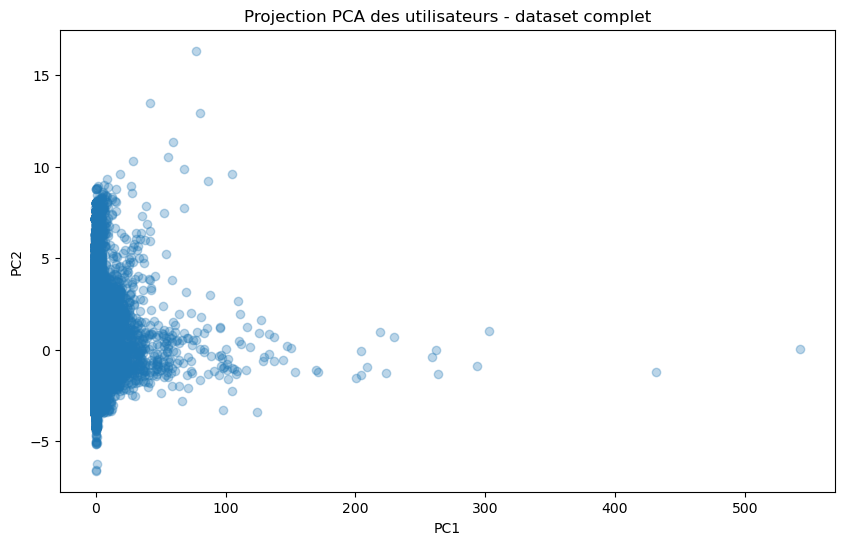

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.scatter(pca_df["PC1"], pca_df["PC2"], alpha=0.3)
plt.title("Projection PCA des utilisateurs - dataset complet")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [16]:
from sklearn.cluster import DBSCAN

In [17]:
dbscan = DBSCAN(
    eps=0.5,
    min_samples=10
)

In [20]:
clusters = dbscan.fit_predict(pca_df)

MemoryError: 

In [19]:
pca_df["cluster"] = clusters

NameError: name 'clusters' is not defined